# Can we predict frequency of cannabis usage based on people's demographics, level of education, self-reported impulsivity levels, and gender?

In [94]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 
from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz 

from ucimlrepo import fetch_ucirepo 
  
# Fetching the dataset

drug_consumption = fetch_ucirepo(id=373) 

# Converting the dataset to a pandas dataframe

drugs_df = pd.concat([drug_consumption.data.features, drug_consumption.data.targets], axis=1)

drugs_df.info() # Printing variable types
drugs_df.head() # Printing the first five rows of the dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [95]:
# Only keeping necessary columns to predict cannabis usage

cannabis_df = drugs_df[['age', 'gender', 'education', 'country', 'ethnicity', 'impuslive', 'cannabis', 'nscore', 'escore', 'oscore', 'ascore', 'cscore', 'ss']]

cannabis_df = cannabis_df.dropna() # Dropping any NA values

cannabis_df.head() # Printing the first five rows of the new dataset

,age,gender,education,country,ethnicity,impuslive,cannabis,nscore,escore,oscore,ascore,cscore,ss
0,0.49788,0.48246,-0.05921,0.96082,0.12600,-0.21712,CL0,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-1.18084
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.71126,CL4,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.21575
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-1.37983,CL3,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,0.40148
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-1.37983,CL2,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.18084
4,0.49788,0.48246,1.98437,0.96082,-0.31685,-0.21712,CL3,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21575


In [96]:
cannabis_df[["cannabis"]] = OrdinalEncoder().fit_transform(cannabis_df[["cannabis"]]) # Ordinally encoding our target variable

print(cannabis_df['cannabis'].value_counts()) # Checking the statistics of each cannabis usage frequency category


cannabis
6.0    463
0.0    413
2.0    266
3.0    211
1.0    207
5.0    185
4.0    140
Name: count, dtype: int64


In [126]:
cannabis_df['education'].unique()

array([-0.05921,  1.98437,  1.16365, -1.22751, -1.7379 ,  0.45468,
       -0.61113, -2.43591, -1.43719])

In [127]:
cannabis_df['country'] = cannabis_df['country'].replace({
    0.96082:'UK', 
    0.24923:'Canada', 
    -0.57009:'USA',
    -0.28519:'Other', 
    -0.09765:'Australia',
    0.21128:'Republic of Ireland', 
    -0.46841:'New Zealand'})

cannabis_df['education'] = cannabis_df['education'].replace({
    -2.43591:"Left school before 16 years",
    -1.73790:"Left school at 16 years",
    -1.43719:"Left school at 17 years",
    -1.22751:"Left school at 18 years",
    -0.61113:"Some college or university, no certificate or degree",
    -0.05921:"Professional certificate/ diploma",
    0.45468:"University degree",
    1.16365:"Masters degree",
    1.98437:"Doctorate degree"
})



In [97]:
# Splitting the data

X = cannabis_df.drop(columns = 'cannabis') # Defining our feature variables
y = cannabis_df.cannabis # Defining our target variable

if isinstance(y, pd.Series):
    y.loc[y <= 2] = 0
    y.loc[(y > 2) & (y <= 6)] = 1

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.70, stratify= y, random_state = 42)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state = 30)

In [98]:
# Starting the cross validation process with 10 splits and 5 repeats

kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 5, random_state=42)

In [99]:
# Defining our scoring metrics

scoring = {
    'roc_auc': 'roc_auc_ovr',             
    'recall': 'recall_macro',               
    'balanced_accuracy': 'balanced_accuracy'  
}



In [100]:
# Using max_depth as our hyperparameter

param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    # "min_samples_leaf":[12,3,4,5,6,7,8,9,10],
    # "min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    # "max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90], 
    # 'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    # 'ccp_alpha':[.001,.01,.1]
        }

In [101]:
cl = DecisionTreeClassifier(random_state=1000) # Defining the classifier model

# Searching for the best classifier based on balanced_accuracy

search = GridSearchCV(cl, param, scoring = scoring, n_jobs = -1, cv = kf, refit = 'balanced_accuracy') 

model = search.fit(X_train, y_train) # Fitting the model based on the training data

In [102]:
# Finding the best max_depth

best = model.best_estimator_
print(best)

DecisionTreeClassifier(max_depth=5, random_state=1000)


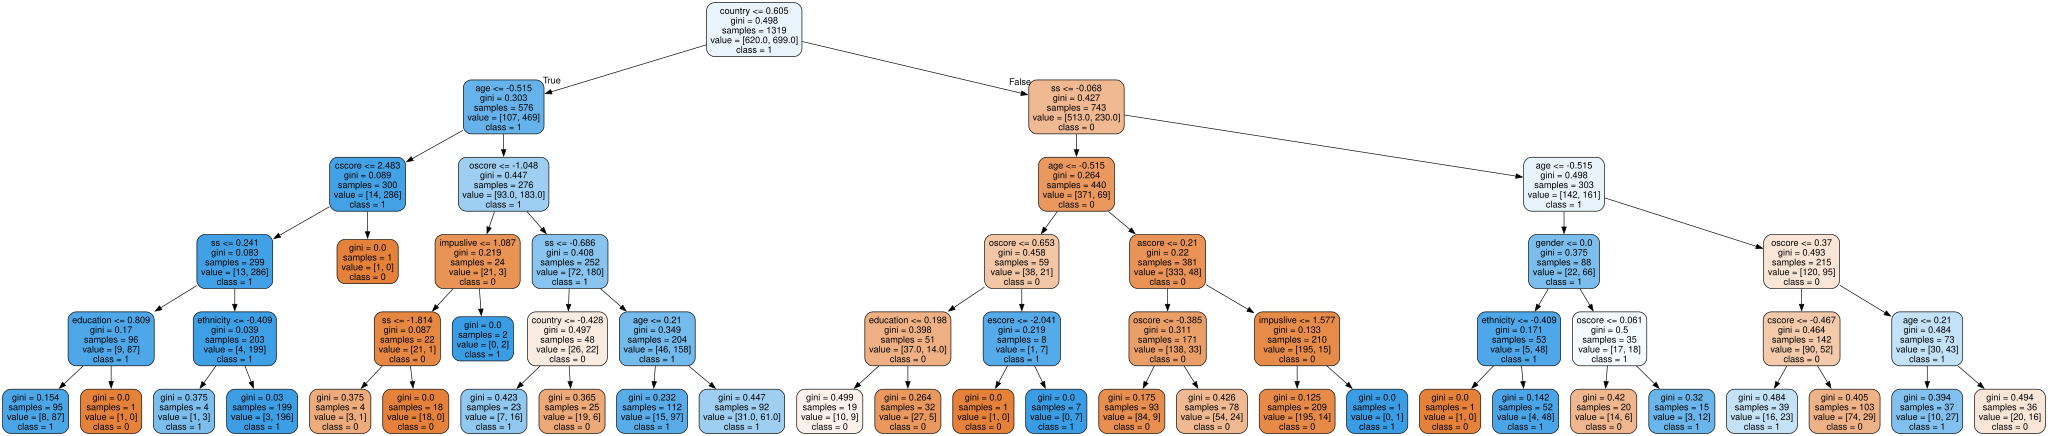

In [103]:
# Printing the decision tree

dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns,
               filled=True, 
                rounded=True, 
                class_names = ['0', '1'])
               
graph=graphviz.Source(dot_data)
graph

In [104]:
print(model.cv_results_)

{'mean_fit_time': array([0.00337221, 0.00309715, 0.00317069, 0.00292019, 0.0037852 ,
       0.00418003, 0.00431739, 0.00517325, 0.00514634, 0.00522821,
       0.00579985, 0.00573042, 0.00624584, 0.00657563, 0.00558608,
       0.00584466, 0.00610313, 0.00590858, 0.0062485 , 0.00624154]), 'std_fit_time': array([0.00131747, 0.00149763, 0.00186391, 0.00128781, 0.00174309,
       0.00188689, 0.00188076, 0.0019725 , 0.00207245, 0.00180727,
       0.00210863, 0.0020677 , 0.00220801, 0.00382217, 0.00196836,
       0.00199794, 0.00194189, 0.00205802, 0.00210128, 0.00169241]), 'mean_score_time': array([0.00566632, 0.00477842, 0.00469946, 0.00492693, 0.00574917,
       0.00489295, 0.005417  , 0.00523499, 0.00538863, 0.00581484,
       0.00530853, 0.00571787, 0.00560819, 0.00543912, 0.00526998,
       0.00579808, 0.00556241, 0.00513175, 0.00503913, 0.00399398]), 'std_score_time': array([0.00273659, 0.00225113, 0.00222938, 0.00332245, 0.00356297,
       0.00269376, 0.00415759, 0.00293526, 0.0030110

In [105]:
auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']


for key in param:
    params = str("param_" + key)

depth= np.unique(model.cv_results_[params])

final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

final_model

,depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
0,1,0.747098,0.747098,0.747098,0.032742,0.032742,0.032742
1,2,0.830229,0.749609,0.749609,0.032518,0.034659,0.034659
2,3,0.843828,0.774279,0.774279,0.028928,0.026548,0.026548
3,4,0.845845,0.767293,0.767293,0.032726,0.032670,0.032670
4,5,0.833875,0.775597,0.775597,0.033973,0.032849,0.032849
5,6,0.813552,0.761515,0.761515,0.040776,0.033405,0.033405
6,7,0.782049,0.753151,0.753151,0.040106,0.037042,0.037042
7,8,0.764280,0.747341,0.747341,0.041034,0.039924,0.039924
8,9,0.744732,0.739174,0.739174,0.043436,0.037923,0.037923
9,10,0.733809,0.733948,0.733948,0.043705,0.040100,0.040100


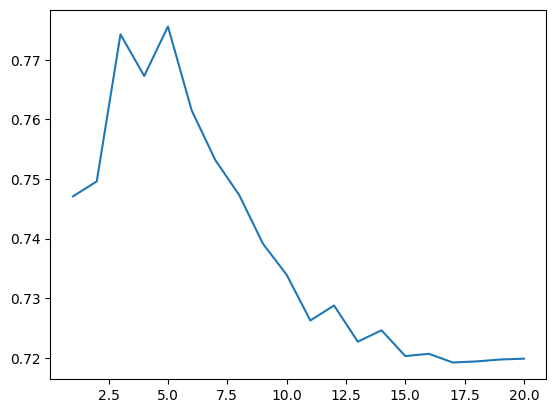

In [106]:
# Finding what depth has the highest balanced accuracy

print(plt.plot(final_model.depth,final_model.bal_acc))

In [107]:
varimp = pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

           importance
country      0.499877
ss           0.173910
age          0.142754
oscore       0.097049
cscore       0.021132
gender       0.018960
impuslive    0.014896
education    0.011927
ascore       0.008177
ethnicity    0.006180
escore       0.005138
nscore       0.000000


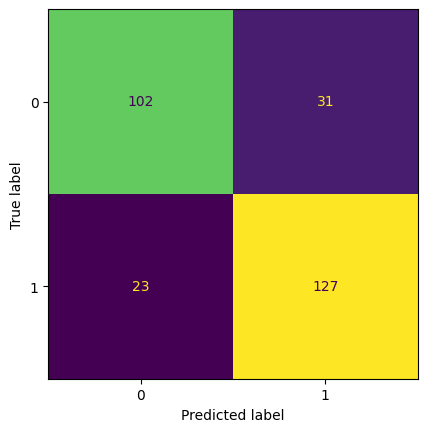

In [108]:
print(ConfusionMatrixDisplay.from_estimator(best, X_tune, y_tune, labels=[0, 1],colorbar=False))